# 📊 Phân tích Kết quả Baseline và Fine-tuned Model


## 1. Import thư viện và Load dữ liệu


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.dpi'] = 100
sns.set_palette("husl")

print("✅ Đã import thư viện thành công!")


✅ Đã import thư viện thành công!


In [2]:
# Đọc dữ liệu từ CSV
baseline_df = pd.read_csv('../output/baseline_results.csv')
finetuned_df = pd.read_csv('../output/finetuned_results.csv')

print(f"📊 Baseline: {len(baseline_df)} mẫu")
print(f"📊 Fine-tuned: {len(finetuned_df)} mẫu")
print(f"\n📋 Cột Baseline: {list(baseline_df.columns)}")
print(f"📋 Cột Fine-tuned: {list(finetuned_df.columns)}")


📊 Baseline: 201 mẫu
📊 Fine-tuned: 201 mẫu

📋 Cột Baseline: ['image', 'ground_truth', 'prediction', 'cer']
📋 Cột Fine-tuned: ['folder', 'image', 'ground_truth', 'prediction', 'cer']


## 2. Merge dữ liệu Baseline và Fine-tuned


In [4]:
def extract_folder_and_image(path):
    """Trích xuất tên thư mục và tên tệp từ đường dẫn đầy đủ"""
    parts = Path(path).parts
    if len(parts) >= 2:
        folder = parts[-2]
        image = parts[-1]
        return folder, image
    return None, None

baseline_df[['folder', 'image_name']] = baseline_df['image'].apply(
    lambda x: pd.Series(extract_folder_and_image(x))
)

baseline_df = baseline_df.rename(columns={
    'prediction': 'baseline_prediction',
    'cer': 'baseline_cer'
})

finetuned_df = finetuned_df.rename(columns={
    'image': 'image_name',
    'prediction': 'finetuned_prediction',
    'cer': 'finetuned_cer'
})

baseline_df['folder'] = baseline_df['folder'].astype(str)
baseline_df['image_name'] = baseline_df['image_name'].astype(str)
finetuned_df['folder'] = finetuned_df['folder'].astype(str)
finetuned_df['image_name'] = finetuned_df['image_name'].astype(str)

merged_df = pd.merge(
    baseline_df[['folder', 'image_name', 'ground_truth', 'baseline_prediction', 'baseline_cer']],
    finetuned_df[['folder', 'image_name', 'finetuned_prediction', 'finetuned_cer']],
    on=['folder', 'image_name'],
    how='inner'
)

merged_df['improvement'] = merged_df['baseline_cer'] - merged_df['finetuned_cer']
merged_df['improvement_pct'] = (merged_df['improvement'] / merged_df['baseline_cer'] * 100).replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"✅ Đã kết hợp thành công {len(merged_df)} mẫu đối chứng")
print(f"\n📊 So sánh chỉ số CER:")
print(f"   - Baseline: Mean = {merged_df['baseline_cer'].mean():.4f}, Median = {merged_df['baseline_cer'].median():.4f}")
print(f"   - Fine-tuned: Mean = {merged_df['finetuned_cer'].mean():.4f}, Median = {merged_df['finetuned_cer'].median():.4f}")
print(f"   - Mức cải thiện: Mean = {merged_df['improvement'].mean():.4f} ({merged_df['improvement_pct'].mean():.1f}%)")

✅ Đã kết hợp thành công 201 mẫu đối chứng

📊 So sánh chỉ số CER:
   - Baseline: Mean = 1.1104, Median = 0.3239
   - Fine-tuned: Mean = 0.1611, Median = 0.1000
   - Mức cải thiện: Mean = 0.9493 (58.0%)


## 3. Phân tích Định lượng (Quantitative Analysis)


In [6]:
# Tính toán thống kê CER
baseline_stats = {
    'Mean': merged_df['baseline_cer'].mean(),
    'Median': merged_df['baseline_cer'].median(),
    'Std': merged_df['baseline_cer'].std(),
    'Min': merged_df['baseline_cer'].min(),
    'Max': merged_df['baseline_cer'].max(),
    'Q25': merged_df['baseline_cer'].quantile(0.25),
    'Q75': merged_df['baseline_cer'].quantile(0.75)
}

finetuned_stats = {
    'Mean': merged_df['finetuned_cer'].mean(),
    'Median': merged_df['finetuned_cer'].median(),
    'Std': merged_df['finetuned_cer'].std(),
    'Min': merged_df['finetuned_cer'].min(),
    'Max': merged_df['finetuned_cer'].max(),
    'Q25': merged_df['finetuned_cer'].quantile(0.25),
    'Q75': merged_df['finetuned_cer'].quantile(0.75)
}

# Tạo bảng so sánh
comparison_df = pd.DataFrame({
    'Baseline': baseline_stats,
    'Fine-tuned': finetuned_stats
})

comparison_df['Improvement'] = comparison_df['Baseline'] - comparison_df['Fine-tuned']
comparison_df['Improvement %'] = (comparison_df['Improvement'] / comparison_df['Baseline'] * 100).round(2)

print("📊 BẢNG SO SÁNH CER")
print("=" * 70)
print(comparison_df.to_string())
print("\n" + "=" * 70)


📊 BẢNG SO SÁNH CER
          Baseline  Fine-tuned  Improvement  Improvement %
Mean      1.110353    0.161081     0.949272          85.49
Median    0.323944    0.100000     0.223944          69.13
Std      10.017131    0.182531     9.834600          98.18
Min       0.000000    0.000000     0.000000            NaN
Max     142.376623    1.333333   141.043290          99.06
Q25       0.200000    0.032787     0.167213          83.61
Q75       0.591549    0.215190     0.376359          63.62



In [7]:
# Thống kê số mẫu có CER = 0 (nhận dạng hoàn hảo)
baseline_perfect = (merged_df['baseline_cer'] == 0).sum()
finetuned_perfect = (merged_df['finetuned_cer'] == 0).sum()

print(f"✅ Số mẫu nhận dạng hoàn hảo (CER = 0):")
print(f"   Baseline: {baseline_perfect} / {len(merged_df)} ({baseline_perfect/len(merged_df)*100:.1f}%)")
print(f"   Fine-tuned: {finetuned_perfect} / {len(merged_df)} ({finetuned_perfect/len(merged_df)*100:.1f}%)")
print(f"   Cải thiện: +{finetuned_perfect - baseline_perfect} mẫu")


✅ Số mẫu nhận dạng hoàn hảo (CER = 0):
   Baseline: 1 / 201 (0.5%)
   Fine-tuned: 28 / 201 (13.9%)
   Cải thiện: +27 mẫu


In [8]:
# Phân tích cải thiện
improved_samples = merged_df[merged_df['improvement'] > 0]
worsened_samples = merged_df[merged_df['improvement'] < 0]
unchanged_samples = merged_df[merged_df['improvement'] == 0]

print(f"📈 Phân tích cải thiện:")
print(f"   Cải thiện: {len(improved_samples)} mẫu ({len(improved_samples)/len(merged_df)*100:.1f}%)")
print(f"   Giảm chất lượng: {len(worsened_samples)} mẫu ({len(worsened_samples)/len(merged_df)*100:.1f}%)")
print(f"   Không đổi: {len(unchanged_samples)} mẫu ({len(unchanged_samples)/len(merged_df)*100:.1f}%)")
print(f"\n   Cải thiện trung bình: {improved_samples['improvement'].mean():.4f} ({improved_samples['improvement_pct'].mean():.1f}%)")
if len(worsened_samples) > 0:
    print(f"   Giảm chất lượng trung bình: {worsened_samples['improvement'].mean():.4f} ({worsened_samples['improvement_pct'].mean():.1f}%)")


📈 Phân tích cải thiện:
   Cải thiện: 186 mẫu (92.5%)
   Giảm chất lượng: 11 mẫu (5.5%)
   Không đổi: 4 mẫu (2.0%)

   Cải thiện trung bình: 1.0333 (66.7%)
   Giảm chất lượng trung bình: -0.1268 (-68.5%)


## 4. Visualization


💾 Đã lưu: cer_distribution_comparison.png


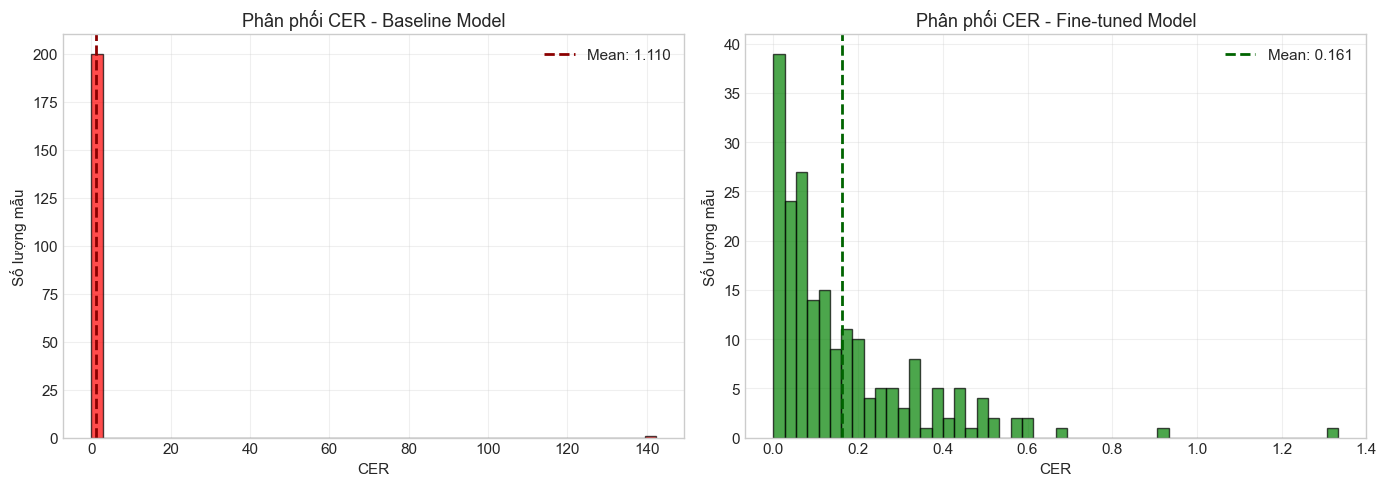

In [9]:
# Histogram so sánh CER
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram Baseline
axes[0].hist(merged_df['baseline_cer'], bins=50, alpha=0.7, color='red', edgecolor='black')
axes[0].axvline(merged_df['baseline_cer'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {merged_df["baseline_cer"].mean():.3f}')
axes[0].set_xlabel('CER')
axes[0].set_ylabel('Số lượng mẫu')
axes[0].set_title('Phân phối CER - Baseline Model')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram Fine-tuned
axes[1].hist(merged_df['finetuned_cer'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(merged_df['finetuned_cer'].mean(), color='darkgreen', linestyle='--', linewidth=2, label=f'Mean: {merged_df["finetuned_cer"].mean():.3f}')
axes[1].set_xlabel('CER')
axes[1].set_ylabel('Số lượng mẫu')
axes[1].set_title('Phân phối CER - Fine-tuned Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/plots/cer_distribution_comparison.png', dpi=150, bbox_inches='tight')
print("💾 Đã lưu: cer_distribution_comparison.png")
plt.show()


💾 Đã lưu: cer_boxplot_comparison.png


C:\Users\ZeePaul\AppData\Local\Temp\ipykernel_2908\2532728295.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Baseline', 'Fine-tuned'], patch_artist=True)


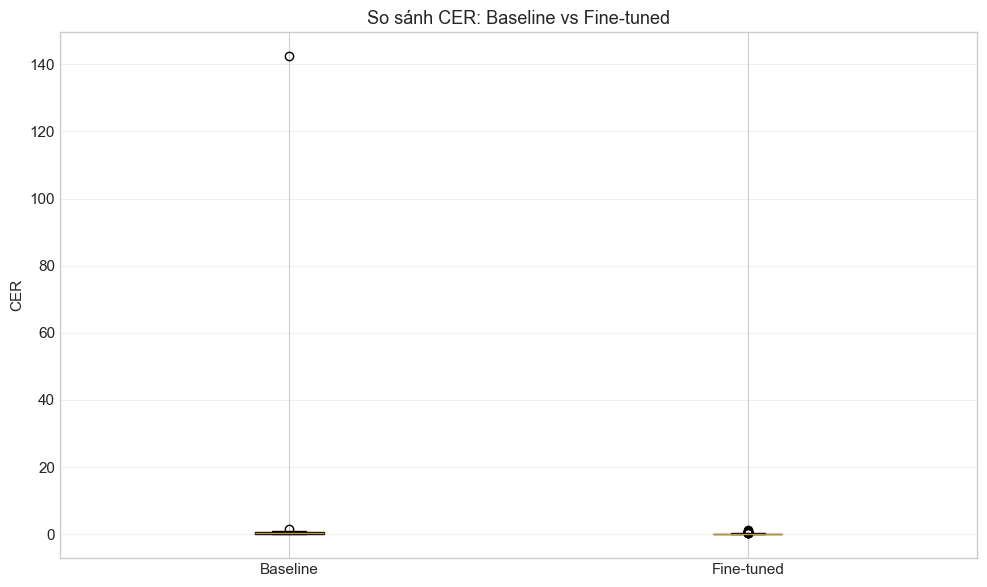

In [10]:
# Box plot so sánh
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = [merged_df['baseline_cer'], merged_df['finetuned_cer']]
bp = ax.boxplot(data_to_plot, labels=['Baseline', 'Fine-tuned'], patch_artist=True)

# Tô màu
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')

ax.set_ylabel('CER')
ax.set_title('So sánh CER: Baseline vs Fine-tuned')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/plots/cer_boxplot_comparison.png', dpi=150, bbox_inches='tight')
print("💾 Đã lưu: cer_boxplot_comparison.png")
plt.show()


💾 Đã lưu: cer_scatter_comparison.png


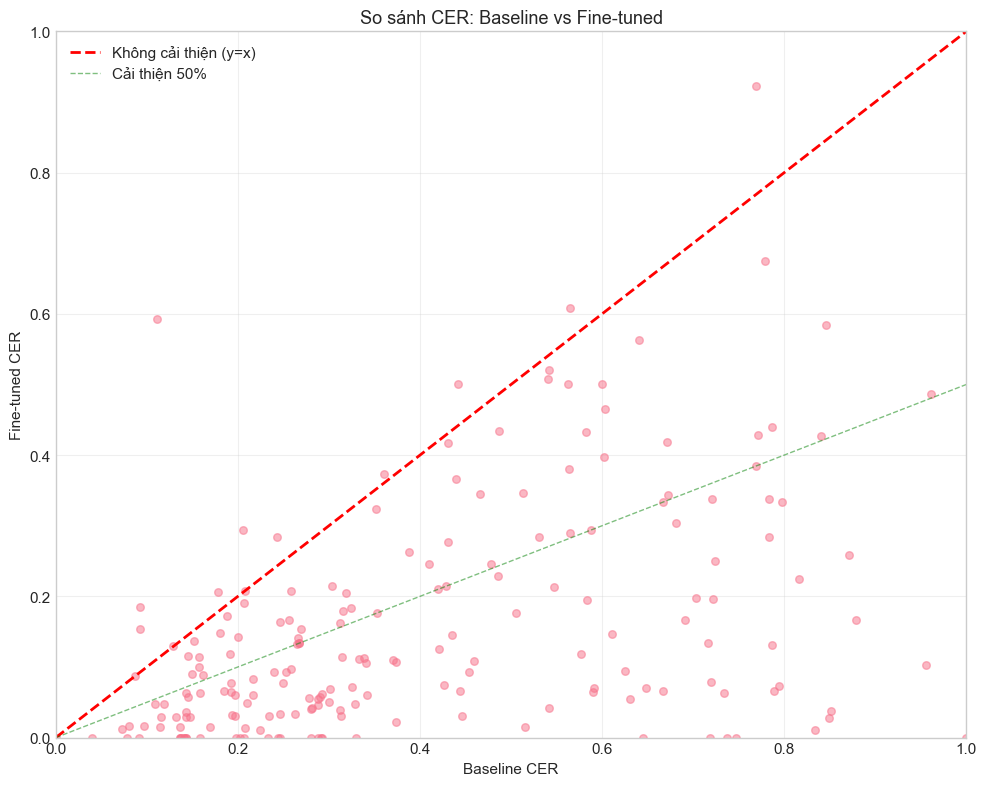

In [11]:
# Scatter plot: Baseline CER vs Fine-tuned CER
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(merged_df['baseline_cer'], merged_df['finetuned_cer'], alpha=0.5, s=30)

# Đường y=x (không cải thiện)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Không cải thiện (y=x)')

# Đường cải thiện 50%
ax.plot([0, 1], [0, 0.5], 'g--', linewidth=1, alpha=0.5, label='Cải thiện 50%')

ax.set_xlabel('Baseline CER')
ax.set_ylabel('Fine-tuned CER')
ax.set_title('So sánh CER: Baseline vs Fine-tuned')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../output/plots/cer_scatter_comparison.png', dpi=150, bbox_inches='tight')
print("💾 Đã lưu: cer_scatter_comparison.png")
plt.show()


## 5. Phân tích Định tính (Qualitative Analysis)


In [12]:
# Top improvements (cải thiện nhiều nhất)
top_improvements = merged_df.nlargest(10, 'improvement')[
    ['folder', 'image_name', 'ground_truth', 'baseline_prediction', 'finetuned_prediction', 
     'baseline_cer', 'finetuned_cer', 'improvement_pct']
]

print("🏆 TOP 10 MẪU CẢI THIỆN NHIỀU NHẤT")
print("=" * 100)
for idx, row in top_improvements.iterrows():
    print(f"\n📸 {row['folder']}/{row['image_name']}")
    print(f"   Ground Truth: {row['ground_truth'][:80]}...")
    print(f"   Baseline:     {row['baseline_prediction'][:80]}...")
    print(f"   Fine-tuned:   {row['finetuned_prediction'][:80]}...")
    print(f"   CER: {row['baseline_cer']:.3f} → {row['finetuned_cer']:.3f} (Cải thiện {row['improvement_pct']:.1f}%)")


🏆 TOP 10 MẪU CẢI THIỆN NHIỀU NHẤT

📸 253/24.jpg
   Ground Truth: các nhà đầu tư trong Khu chế xuất Tân Thuận. Vậy thì khi không khắc phục ngay...
   Baseline:     салчын дүнүн кур болгон дүн сүнүн "Тонн Чынын" үнүн чынын дүнүн "Тонн Чынын" үнү...
   Fine-tuned:   các nghề dầu lư trong khi đã xuất " tôm Thượng. Vận thủ không khỏi phức tạp, ngà...
   CER: 142.377 → 0.390 (Cải thiện 99.7%)

📸 254/8.jpg
   Ground Truth: 330.000 km2)...
   Baseline:     \[ 330.000 \, \text{km}^2 \]...
   Fine-tuned:   330.000 km2....
   CER: 1.417 → 0.083 (Cải thiện 94.1%)

📸 250/24.jpg
   Ground Truth: đất....
   Baseline:     书法...
   Fine-tuned:   đất....
   CER: 1.000 → 0.000 (Cải thiện 100.0%)

📸 250/14.jpg
   Ground Truth: ta thực hiện hai cơ chế (vừa Nhà nước thực hiện thu hồi đất như cách...
   Baseline:     на что ни к чему, если сонно, когда надо, то что ни в чем, так и тому, когда...
   Fine-tuned:   ra thuốc hiệu hai cơ chế (vừa nhà nước thuốc hiệu thu hồi đất như cách...
   CER: 0.956 → 0.103 (

In [13]:
# Worst cases sau fine-tuning (vẫn còn lỗi cao)
worst_cases = merged_df.nlargest(10, 'finetuned_cer')[
    ['folder', 'image_name', 'ground_truth', 'baseline_prediction', 'finetuned_prediction', 
     'baseline_cer', 'finetuned_cer', 'improvement_pct']
]

print("\n⚠️ TOP 10 MẪU VẪN CÒN LỖI CAO SAU FINE-TUNING")
print("=" * 100)
for idx, row in worst_cases.iterrows():
    print(f"\n📸 {row['folder']}/{row['image_name']}")
    print(f"   Ground Truth: {row['ground_truth'][:80]}...")
    print(f"   Baseline:     {row['baseline_prediction'][:80]}...")
    print(f"   Fine-tuned:   {row['finetuned_prediction'][:80]}...")
    print(f"   CER: {row['baseline_cer']:.3f} → {row['finetuned_cer']:.3f}")



⚠️ TOP 10 MẪU VẪN CÒN LỖI CAO SAU FINE-TUNING

📸 255/7.jpg
   Ground Truth: ngờ...
   Baseline:     hā...
   Fine-tuned:   tốt....
   CER: 1.000 → 1.333

📸 253/13.jpg
   Ground Truth: hiệu hiệp sĩ....
   Baseline:     him angry...
   Fine-tuned:   hẹn huyện Đà Lạt....
   CER: 0.769 → 0.923

📸 253/39.jpg
   Ground Truth: như làm chạnh lòng tôi là có phải họ đã xả thân vì đại nghĩa để rồi gia đình,...
   Baseline:     when some changes in the pattern of the x-axis and y-axis in the figure, the...
   Fine-tuned:   như bản chất này, bình phí hạ đã xả 1% nữa, đã gây ảnh hưởng đến " giá trị " gia...
   CER: 0.779 → 0.675

📸 253/34.jpg
   Ground Truth: những sai phạm đó. Có như vậy niềm tin vào lẽ phải mới được khôi phục...
   Baseline:     ending! Mai làm đi - có những ngày làm - gần như là phải mất đi chút phải....
   Fine-tuned:   những nữa làm " đế ". Có những ngày mặn, gần vừa là phía nước để khẳng định,...
   CER: 0.565 → 0.609

📸 251/26.jpg
   Ground Truth: đưa tốc độ tăng trưởng GDP 

In [14]:
# Best cases (nhận dạng hoàn hảo sau fine-tuning)
perfect_cases = merged_df[merged_df['finetuned_cer'] == 0].head(10)[
    ['folder', 'image_name', 'ground_truth', 'baseline_prediction', 'finetuned_prediction', 
     'baseline_cer', 'finetuned_cer']
]

print("\n✨ TOP 10 MẪU NHẬN DẠNG HOÀN HẢO (CER = 0)")
print("=" * 100)
for idx, row in perfect_cases.iterrows():
    print(f"\n📸 {row['folder']}/{row['image_name']}")
    print(f"   Ground Truth: {row['ground_truth']}")
    print(f"   Baseline CER: {row['baseline_cer']:.3f}")
    print(f"   Fine-tuned:   {row['finetuned_prediction']}")
    print(f"   ✅ Hoàn hảo!")



✨ TOP 10 MẪU NHẬN DẠNG HOÀN HẢO (CER = 0)

📸 250/11.jpg
   Ground Truth: Chưa kể để doanh nghiệp và người dân " nói chuyện " với nhau như
   Baseline CER: 0.719
   Fine-tuned:   chưa kể để doanh nghiệp và người dân " nói chuyện " với nhau như
   ✅ Hoàn hảo!

📸 250/21.jpg
   Ground Truth: chúng ta cần thay đổi trong quan điểm, không nên để hệ thống hành chính
   Baseline CER: 0.141
   Fine-tuned:   chúng ta cần thay đổi trong quan điểm, không nên để hệ thống hành chính
   ✅ Hoàn hảo!

📸 250/24.jpg
   Ground Truth: đất.
   Baseline CER: 1.000
   Fine-tuned:   đất.
   ✅ Hoàn hảo!

📸 250/25.jpg
   Ground Truth: Ngay cả trường hợp ta không qui định, người dân và doanh nghiệp vẫn thực hiện
   Baseline CER: 0.078
   Fine-tuned:   Ngay cả trường hợp ta không qui định, người dân và doanh nghiệp vẫn thực hiện
   ✅ Hoàn hảo!

📸 251/1.jpg
   Ground Truth: Chương trình hành động thực hiện Nghị quyết trung ương 9 - khóa
   Baseline CER: 0.159
   Fine-tuned:   Chương trình hành động thực hiện Nghị q

## 6. Phân tích theo Folder


In [15]:
# Tính CER trung bình theo folder
folder_stats = merged_df.groupby('folder').agg({
    'baseline_cer': ['mean', 'std', 'count'],
    'finetuned_cer': ['mean', 'std'],
    'improvement': 'mean'
}).round(4)

folder_stats.columns = ['baseline_mean', 'baseline_std', 'count', 'finetuned_mean', 'finetuned_std', 'improvement_mean']
folder_stats = folder_stats.sort_values('improvement_mean', ascending=False)

print("📊 THỐNG KÊ CER THEO FOLDER")
print("=" * 100)
print(folder_stats.head(20).to_string())


📊 THỐNG KÊ CER THEO FOLDER
        baseline_mean  baseline_std  count  finetuned_mean  finetuned_std  improvement_mean
folder                                                                                     
253            3.8343       21.3724     44          0.3898         0.1452            3.4446
250            0.4575        0.2631     37          0.1165         0.0840            0.3410
254            0.3813        0.3286     21          0.0460         0.1087            0.3353
255            0.4376        0.2670     24          0.1317         0.2708            0.3059
252            0.2560        0.1335     35          0.0904         0.0613            0.1655
251            0.2518        0.1551     40          0.0906         0.1018            0.1612


## 7. Lưu kết quả Merged CSV


In [16]:
# Lưu merged results với đầy đủ thông tin
output_columns = [
    'folder', 'image_name', 'ground_truth', 
    'baseline_prediction', 'baseline_cer',
    'finetuned_prediction', 'finetuned_cer',
    'improvement', 'improvement_pct'
]

merged_df[output_columns].to_csv('../output/merged_results.csv', index=False, encoding='utf-8')
print(f"✅ Đã lưu merged_results.csv với {len(merged_df)} mẫu")
print(f"📁 Đường dẫn: ../output/merged_results.csv")


✅ Đã lưu merged_results.csv với 201 mẫu
📁 Đường dẫn: ../output/merged_results.csv
